In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))  # ../src
sys.path.append(src_path)

from fun import get_percentile_filtered, compute_survival_function
from plot import plot_total_nights_distribution, plot_sf_total_nights, plot_cancellation_nights_week_end, plot_leadtime_decay, plot_leadtime_cancel

sns.set(style="whitegrid") 
df_clean = pd.read_parquet('../data/hotels_clean.parquet' , engine='fastparquet') 
print(f"Cleaned dataset shape: {df_clean.shape}")
display(df_clean.head(3))

Cleaned dataset shape: (78528, 19)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,total_guests,total_nights
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,0,0,0,A,C,1,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,0,0,0,A,A,1,1
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,0,0,0,A,A,2,2


In [2]:
# --- Filter dataset to exclude unusual bookings ---
#   - guests: adults ≤ 4 & children ≤ 3
#   - stay nights: total_nights ≤ 14 (99% percentile covers most of the data)

df_filtered = df_clean[
    (df_clean['adults'] <= 4) & 
    (df_clean['children'] <= 3) & 
    (df_clean['total_nights'] <= 14) 
].copy()

Figure saved to ../figures/leadtime_cancel.png


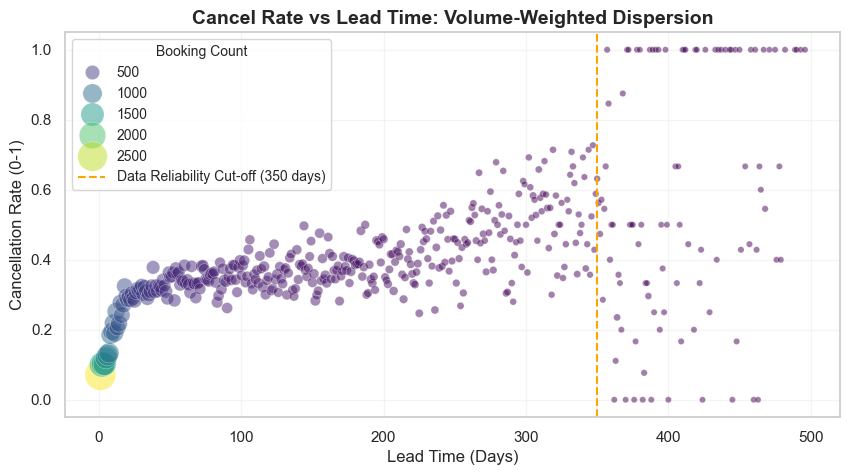

In [3]:
plot_leadtime_cancel(df_filtered, min_lead=0, max_lead=500, cutoff_day=350,
                     save_path="../figures/leadtime_cancel.png")

In [4]:
lead_time_counts = df_filtered.groupby('lead_time').agg(booking_count=('is_canceled', 'count'), cancel_rate=('is_canceled', 'mean')).reset_index()
df_mask = lead_time_counts[(lead_time_counts['lead_time'] > 0) & (lead_time_counts['lead_time'] < 350)]

df_filtered = df_clean[
    (df_clean['adults'] <= 4) & 
    (df_clean['children'] <= 3) & 
    (df_clean['total_nights'] <= 14) &
    (df_clean['lead_time'] > 0) & 
    (df_clean['lead_time'] < 350)
].copy()

filtered_nights = get_percentile_filtered(df_filtered, 'lead_time', [0.90,0.95, 0.98, 0.99])
data_plot_90 = filtered_nights[0.90]
data_plot_95 = filtered_nights[0.95]
data_plot_98 = filtered_nights[0.98]
data_plot_99 = filtered_nights[0.99]

90% of bookings have lead_time ≤ 199
95% of bookings have lead_time ≤ 243
98% of bookings have lead_time ≤ 292
99% of bookings have lead_time ≤ 316


Figure saved to ../figures/leadtime_decay_90p.png


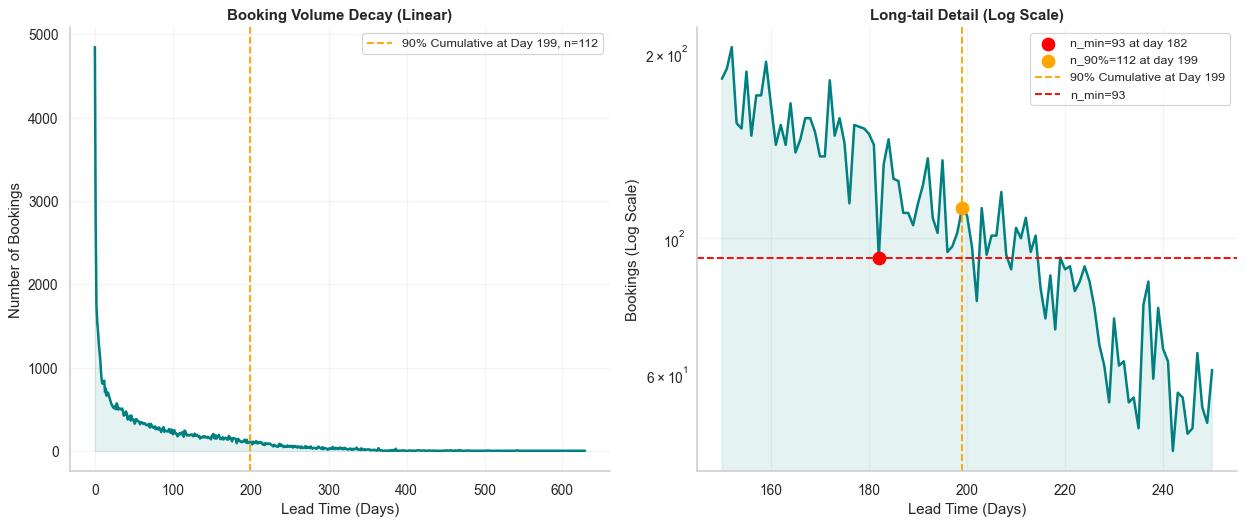

In [5]:
plot_leadtime_decay(df_mask=lead_time_counts, pct_threshold=0.9, zoom_range=(150,250),
                    save_path="../figures/leadtime_decay_90p.png")